In [6]:
%pip install scikit-learn pandas numpy matplotlib seaborn

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)
import pickle
import os

print("✅ Semua library berhasil diimport!")

✅ Semua library berhasil diimport!


In [8]:

df = pd.read_csv('../komentar_bersih.csv')

print(f"✅ Dataset loaded: {len(df)} komentar")
print(f"Kolom: {df.columns.tolist()}")
print(f"\nDistribusi label:")
print(df['label'].value_counts())
df.head()

✅ Dataset loaded: 4668 komentar
Kolom: ['teks', 'label', 'teks_asli', 'teks_bersih', 'ada_unicode_font', 'ada_nama_situs', 'ada_angka_judi', 'ada_caps_aneh', 'ada_keyword_judi']

Distribusi label:
label
1.0    3025
0.0    1177
Name: count, dtype: int64


,teks,label,teks_asli,teks_bersih,ada_unicode_font,ada_nama_situs,ada_angka_judi,ada_caps_aneh,ada_keyword_judi
0,Lah ke sol*r*a yg nunggu 1 jam aja masih gw tu...,0.0,Lah ke sol*r*a yg nunggu 1 jam aja masih gw tu...,lah ke sol r a yg nunggu i jam aja masih gw tu...,1.0,0.0,0.0,0.0,0.0
1,"Waktu tunggu normal kok, kalau gak mau ngantri...",0.0,"Waktu tunggu normal kok, kalau gak mau ngantri...",waktu tunggu normal kok kalau gak mau ngantri ...,1.0,0.0,0.0,0.0,0.0
2,Murah sih daripada bakso tetelan di atas tadi ...,0.0,Murah sih daripada bakso tetelan di atas tadi ...,murah sih daripada bakso tetelan di atas tadi ...,0.0,0.0,0.0,0.0,0.0
3,emang dasar konsumen masih banyak yg ga sabara...,0.0,emang dasar konsumen masih banyak yg ga sabara...,emang dasar konsumen masih banyak yg ga sabara...,1.0,0.0,0.0,0.0,1.0
4,15 menit mah bentar banget😂,0.0,15 menit mah bentar banget😂,is menit mah bentar banget,1.0,0.0,0.0,0.0,0.0


In [9]:
# Cek kondisi data dulu
print("Cek data sebelum diproses:")
print(f"Total data          : {len(df)}")
print(f"Label kosong (NaN)  : {df['label'].isna().sum()}")
print(f"Teks kosong (NaN)   : {df['teks_bersih'].isna().sum()}")
print(f"\nNilai unik label: {df['label'].unique()}")

# Hapus baris yang labelnya kosong
df = df.dropna(subset=['label', 'teks_bersih'])

# Hapus nilai label yang tidak valid (selain 0 dan 1)
df = df[df['label'].isin([0, 1, 0.0, 1.0])]

# Baru ubah ke integer
X = df['teks_bersih'].fillna('')
y = df['label'].astype(int)

# Split 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\n✅ Data berhasil di-split!")
print(f"   Training : {len(X_train)} data")
print(f"   Testing  : {len(X_test)} data")
print(f"\nDistribusi label training:")
print(y_train.value_counts())
print(f"\nDistribusi label testing:")
print(y_test.value_counts())

Cek data sebelum diproses:
Total data          : 4668
Label kosong (NaN)  : 466
Teks kosong (NaN)   : 466

Nilai unik label: [ 0.  1. nan]

✅ Data berhasil di-split!
   Training : 3361 data
   Testing  : 841 data

Distribusi label training:
label
1    2420
0     941
Name: count, dtype: int64

Distribusi label testing:
label
1    605
0    236
Name: count, dtype: int64


In [10]:
# Ubah teks menjadi angka menggunakan TF-IDF
tfidf = TfidfVectorizer(
    max_features=10000,   # ambil 10.000 kata paling penting
    ngram_range=(1, 2),   # unigram + bigram
    min_df=2,             # abaikan kata yang muncul < 2 kali
    sublinear_tf=True     # normalisasi frekuensi
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("✅ TF-IDF selesai!")
print(f"   Jumlah fitur/kata : {X_train_tfidf.shape[1]}")
print(f"   Shape training    : {X_train_tfidf.shape}")
print(f"   Shape testing     : {X_test_tfidf.shape}")

✅ TF-IDF selesai!
   Jumlah fitur/kata : 5557
   Shape training    : (3361, 5557)
   Shape testing     : (841, 5557)


In [11]:
# Definisi semua model yang akan dicoba
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        random_state=42,
        C=1.0
    ),
    'Naive Bayes': MultinomialNB(
        alpha=0.1
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )
}

# Training & evaluasi semua model
hasil_semua = {}

print("⏳ Training semua model...\n")
print("=" * 60)

for nama, model in models.items():
    print(f"🔄 Training: {nama}...")

    # Training
    model.fit(X_train_tfidf, y_train)

    # Prediksi
    y_pred = model.predict(X_test_tfidf)

    # Hitung metrik
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')

    hasil_semua[nama] = {
        'model': model,
        'y_pred': y_pred,
        'accuracy': acc,
        'f1_score': f1
    }

    print(f"   ✅ Accuracy : {acc:.4f} ({acc*100:.2f}%)")
    print(f"   ✅ F1-Score : {f1:.4f} ({f1*100:.2f}%)")
    print()

print("=" * 60)
print("✅ Semua model selesai di-training!")

⏳ Training semua model...

🔄 Training: Logistic Regression...
   ✅ Accuracy : 0.9168 (91.68%)
   ✅ F1-Score : 0.9132 (91.32%)

🔄 Training: Naive Bayes...
   ✅ Accuracy : 0.9453 (94.53%)
   ✅ F1-Score : 0.9453 (94.53%)

🔄 Training: Random Forest...
   ✅ Accuracy : 0.9548 (95.48%)
   ✅ F1-Score : 0.9550 (95.50%)

✅ Semua model selesai di-training!


📊 PERBANDINGAN HASIL MODEL
Model                       Accuracy   F1-Score
--------------------------------------------------
Logistic Regression           91.68%     91.32%
Naive Bayes                   94.53%     94.53%
Random Forest                 95.48%     95.50% ⭐
--------------------------------------------------

🏆 Model terbaik: Random Forest (F1: 95.50%)


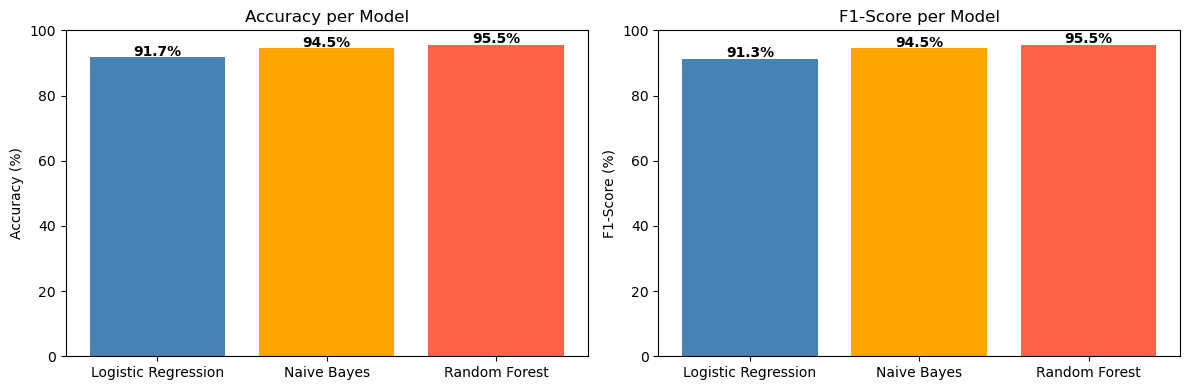

In [12]:
# Tabel perbandingan
print("=" * 50)
print("📊 PERBANDINGAN HASIL MODEL")
print("=" * 50)
print(f"{'Model':<25} {'Accuracy':>10} {'F1-Score':>10}")
print("-" * 50)

model_terbaik_nama = None
f1_terbaik = 0

for nama, hasil in hasil_semua.items():
    acc = hasil['accuracy']
    f1 = hasil['f1_score']
    bintang = " ⭐" if f1 == max(h['f1_score'] for h in hasil_semua.values()) else ""
    print(f"{nama:<25} {acc*100:>9.2f}% {f1*100:>9.2f}%{bintang}")
    if f1 > f1_terbaik:
        f1_terbaik = f1
        model_terbaik_nama = nama

print("-" * 50)
print(f"\n🏆 Model terbaik: {model_terbaik_nama} (F1: {f1_terbaik*100:.2f}%)")

# Visualisasi perbandingan
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

nama_models = list(hasil_semua.keys())
accuracies = [hasil_semua[n]['accuracy']*100 for n in nama_models]
f1_scores = [hasil_semua[n]['f1_score']*100 for n in nama_models]

ax1.bar(nama_models, accuracies, color=['steelblue','orange','tomato'])
ax1.set_title('Accuracy per Model')
ax1.set_ylabel('Accuracy (%)')
ax1.set_ylim([0, 100])
for i, v in enumerate(accuracies):
    ax1.text(i, v+0.5, f'{v:.1f}%', ha='center', fontweight='bold')

ax2.bar(nama_models, f1_scores, color=['steelblue','orange','tomato'])
ax2.set_title('F1-Score per Model')
ax2.set_ylabel('F1-Score (%)')
ax2.set_ylim([0, 100])
for i, v in enumerate(f1_scores):
    ax2.text(i, v+0.5, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

📋 CLASSIFICATION REPORT — Random Forest
              precision    recall  f1-score   support

  Normal (0)       0.91      0.93      0.92       236
    Judi (1)       0.97      0.96      0.97       605

    accuracy                           0.95       841
   macro avg       0.94      0.95      0.94       841
weighted avg       0.96      0.95      0.95       841



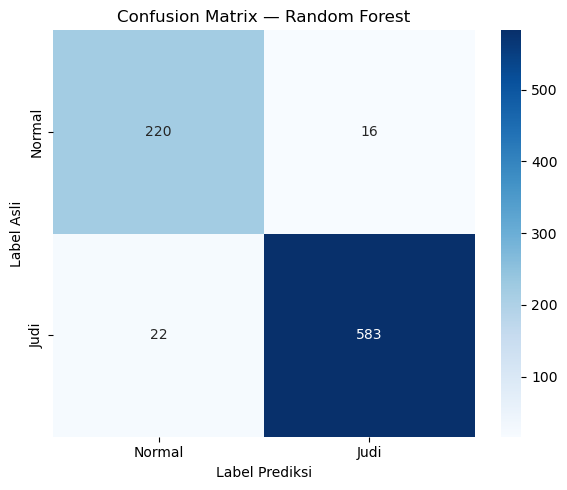


📊 Detail Confusion Matrix:
   ✅ True Negative  (Normal diprediksi Normal) : 220
   ✅ True Positive  (Judi diprediksi Judi)     : 583
   ⚠️  False Positive (Normal diprediksi Judi)  : 16
   ⚠️  False Negative (Judi diprediksi Normal)  : 22


In [13]:
print(f"📋 CLASSIFICATION REPORT — {model_terbaik_nama}")
print("=" * 60)

y_pred_terbaik = hasil_semua[model_terbaik_nama]['y_pred']
print(classification_report(
    y_test, y_pred_terbaik,
    target_names=['Normal (0)', 'Judi (1)']
))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_terbaik)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Normal', 'Judi'],
    yticklabels=['Normal', 'Judi']
)
plt.title(f'Confusion Matrix — {model_terbaik_nama}')
plt.ylabel('Label Asli')
plt.xlabel('Label Prediksi')
plt.tight_layout()
plt.show()

# Penjelasan confusion matrix
tn, fp, fn, tp = cm.ravel()
print(f"\n📊 Detail Confusion Matrix:")
print(f"   ✅ True Negative  (Normal diprediksi Normal) : {tn}")
print(f"   ✅ True Positive  (Judi diprediksi Judi)     : {tp}")
print(f"   ⚠️  False Positive (Normal diprediksi Judi)  : {fp}")
print(f"   ⚠️  False Negative (Judi diprediksi Normal)  : {fn}")

In [14]:
import re, unicodedata

UNICODE_FONT_MAP = {}
unicode_ranges = [
    (0x1D400, 'A'), (0x1D41A, 'a'),
    (0x1D434, 'A'), (0x1D44E, 'a'),
    (0x1D468, 'A'), (0x1D482, 'a'),
    (0x1D49C, 'A'), (0x1D4B6, 'a'),
    (0x1D4D0, 'A'), (0x1D4EA, 'a'),
    (0x1D504, 'A'), (0x1D51E, 'a'),
    (0x1D538, 'A'), (0x1D552, 'a'),
    (0x1D56C, 'A'), (0x1D586, 'a'),
    (0x1D5A0, 'A'), (0x1D5BA, 'a'),
    (0x1D5D4, 'A'), (0x1D5EE, 'a'),
    (0x1D608, 'A'), (0x1D622, 'a'),
    (0x1D63C, 'A'), (0x1D656, 'a'),
    (0x1D670, 'A'), (0x1D68A, 'a'),
]
for start, base_char in unicode_ranges:
    for i in range(26):
        UNICODE_FONT_MAP[chr(start + i)] = chr(ord(base_char) + i)
for i in range(10):
    UNICODE_FONT_MAP[chr(0x1D7CE + i)] = str(i)

# ============================================
# PERBAIKAN: Angka TIDAK diubah ke huruf
# Hanya simbol yang memang pengganti huruf
# ============================================
SIMBOL_MAP = {
    '@': 'a',
    '|': 'l',
    '$': 's',
    '!': 'i',
}

# Ganti simbol angka HANYA jika diapit huruf (bukan nama situs)
# Contoh: g4cor → gacor, tapi RAJA303 tetap raja303
def ganti_simbol_di_kata(teks):
    """
    Ganti angka yang jadi pengganti huruf di DALAM kata
    tapi pertahankan angka yang berdiri sendiri (nama situs)
    """
    # g4cor → gacor (angka di tengah kata)
    teks = re.sub(r'(?<=[a-z])4(?=[a-z])', 'a', teks)
    teks = re.sub(r'(?<=[a-z])3(?=[a-z])', 'e', teks)
    teks = re.sub(r'(?<=[a-z])0(?=[a-z])', 'o', teks)
    teks = re.sub(r'(?<=[a-z])1(?=[a-z])', 'i', teks)
    teks = re.sub(r'(?<=[a-z])5(?=[a-z])', 's', teks)
    # Angka di akhir/awal kata dibiarkan (303, 777, 88)
    return teks

def konversi_unicode_font(teks):
    hasil = ''
    for char in str(teks):
        if char in UNICODE_FONT_MAP:
            hasil += UNICODE_FONT_MAP[char]
        else:
            hasil += unicodedata.normalize('NFKC', char)
    return hasil

def normalisasi_teks(teks):
    teks = str(teks)
    teks = konversi_unicode_font(teks)
    teks = teks.lower()
    # Ganti simbol huruf dulu
    for simbol, huruf in SIMBOL_MAP.items():
        teks = teks.replace(simbol, huruf)
    # Ganti angka pengganti huruf di dalam kata saja
    teks = ganti_simbol_di_kata(teks)
    # Hapus URL
    teks = re.sub(r'http\S+|www\S+|bit\.ly\S+', '', teks)
    # Pisahkan huruf+angka (raja303 → raja 303)
    teks = re.sub(r'([a-z])(\d)', r'\1 \2', teks)
    teks = re.sub(r'(\d)([a-z])', r'\1 \2', teks)
    # Bersihkan karakter tidak perlu
    teks = re.sub(r'[^\w\s]', ' ', teks)
    teks = re.sub(r'\s+', ' ', teks).strip()
    return teks

# Test perbaikan normalisasi
print("Test normalisasi yang diperbaiki:")
print("-" * 55)
test = [
    ("RAJA303", "seharusnya → raja 303"),
    ("g4cor", "seharusnya → gacor"),
    ("s|0t", "seharusnya → slot"),
    ("PULAu777", "seharusnya → pulau 777"),
]
for teks, keterangan in test:
    print(f"{teks:15} → {normalisasi_teks(teks):20} ({keterangan})")

Test normalisasi yang diperbaiki:
-------------------------------------------------------
RAJA303         → raja 303             (seharusnya → raja 303)
g4cor           → gacor                (seharusnya → gacor)
s|0t            → slot                 (seharusnya → slot)
PULAu777        → pulau 777            (seharusnya → pulau 777)


In [15]:
# ============================================
# PERBAIKAN: Tambah deteksi keyword + threshold
# ============================================

# Keyword dan pola nama situs yang pasti judi
KEYWORD_PASTI_JUDI = [
    'slot', 'gacor', 'maxwin', 'jackpot', 'scatter',
    'togel', 'casino', 'poker', 'withdraw', 'deposit',
    'jp', 'bet', 'spin', 'daftar sekarang', 'link di bio',
    'hub admin', 'wa admin', 'cuan', 'menang terus',
'slot', 'gacor', 'maxwin', 'jackpot', 'jp',
    'scatter', 'togel', 'casino', 'poker', 'bet',
    'daftar', 'withdraw', 'deposit', 'bonus',
    'link di bio', 'hub admin', 'wa admin',
    'cuan', 'menang terus', 'modal kecil',
    'pulau', 'raja', 'spin', 'hoki',

    # Karakter & Game
    'zeus', 'kakek zeus', 'kakek merah', 'petir', 'olympus',
    'mahjong', 'mahjong ways', 'princess', 'starlight', 'spaceman',
    'pragmatic', 'pg soft', 'x500', 'x250', 'pecah',

    # Slang & Teknis
    'rtp', 'rtp live', 'pola', 'bocoran', 'rungkad',
    'rungkat', 'anti rungkad', 'depo', 'wd', 'wede',
    'to', 'turnover', 'garansi kekalahan', 'modal receh', 'gampang menang',
    'pasti jp', 'new member', 'freebet', 'bonus new member', 'situs terpercaya',
    'agen resmi', 'link rtp', 'sikat', 'klik link', 'cek profil',
    'join sekarang', 'situs gacor',

    # Bypass & Typo
    'sl0t', 's l o t', 's|ot', '5lot', 'gac0r', 'g4cor', 'z3us', 'zeu5',

    # Typo Ekstrem & Leetspeak
    'sketer', 'seketer', 'jekpot', 'm4xwin', 'maxw1n', 'g4c0r', '5l0t', 'sl0t gacor',

    # Istilah Orang Dalam & Trik
    'info pusat', 'admin jarwo', 'admin riki', 'jam gacor', 'pola gacor', 'trik gacor',

    # Metode Transaksi & Rayuan
    'depo pulsa', 'tanpa potongan', 'via dana', 'via ovo', 'via gopay', 'via qris', 'qris',
    'auto wd', 'jamin wd', 'anti sedot', 'pasti bayar', 'lunas', 'cair',

    # Provider & Game Lainnya
    'habanero', 'microgaming', 'sbobet', 'joker123', 'joker gaming', 'spadegaming',
    'gatot kaca', 'gatotkaca', 'koi gate', 'sugar rush', 'sweet bonanza',

    # Jenis Judi Lainnya
    'parlay', 'mix parlay', 'roulette', 'baccarat', 'sicbo', 'domino', 'qiuqiu', 'qq', 'pkv', 'bandarq',
    'bola jalan', 'tebak skor', 'taruhan', 'judi', 'judol',

    # Istilah Komunitas & Link
    'slotter', 'slotters', 'member baru', 'vip', 'v.i.p', 'link alternatif', 'anti nawala', 'bebas ip',

    # Emoji & Ikon
    '🎰', '🎲', '🃏', '♠️', '♣️', '♥️', '♦️', '💰', '💸', '💵', '🤑', '💎',
    '⚡', '⚡⚡', '⚡⚡⚡', '💣', '💥', '🚀',
    '🔥', '🔥🔥', '🚨', '⚠️', '✅', '✔️', '💯', '👇', '➡️', '🔗', '📌',

    # Kombinasi Teks dan Emoji
    'gacor🔥', 'zeus⚡', 'slot🎰', 'maxwin🚀', 'maxwin💰', 'cuan🤑', 'depo💸',
    'wd💸', 'pecah💥', 'link👇', 'daftar✅', 'jp💯', 'rtp🔥', 'x500⚡',

    # --- TAMBAHAN BARU: TANDA BACA & SIMBOL MANIPULASI ---

    # Kurung Khusus (Sering untuk membingkai nama situs agar mencolok)
    '【', '】', '「', '」', '『', '』', '[', ']', '{', '}', '<', '>',

    # Penekanan Hiperbolik & Panah (Mengarahkan mata ke link)
    '!!!', '!!', '??', '>>', '<<', '==>', '-->', '=>', '->', '>>>', '<<<',

    # Garis Pemisah / Tanda Pipa (Bypass spasi atau pemisah kata)
    '|', '||', '/', '//', '\\', '_', '-', '--',

    # Simbol Dekoratif / Sensor
    '***', '+++', '===', '~~', '•••', '^^', '$$', '$$$'
]

# Pola nama situs (huruf + angka judi)
POLA_NAMA_SITUS = [
    r'raja\s*\d+', r'pulau\s*\d+', r'slot\s*\d+',
    r'spin\s*\d+', r'jp\s*\d+', r'maxwin\s*\d+',
    r'\w+\s*(777|303|88|99|168|365|4d|2d)\b',
]

def prediksi_komentar(teks_input, model, vectorizer):
    """
    Prediksi dengan 3 lapis:
    Lapis 1: Cek keyword pasti judi → langsung flag
    Lapis 2: Cek pola nama situs   → langsung flag
    Lapis 3: Model ML + threshold  → prediksi
    """
    teks_bersih = normalisasi_teks(teks_input)

    # Lapis 1: Cek keyword eksplisit
    for kw in KEYWORD_PASTI_JUDI:
        if kw in teks_bersih:
            print(f"Komentar   : {teks_input}")
            print(f"Teks bersih: {teks_bersih}")
            print(f"Hasil      : 🔴 JUDI (keyword: '{kw}')")
            print(f"Confidence : 100% keyword match")
            print("-" * 55)
            return

    # Lapis 2: Cek pola nama situs
    for pola in POLA_NAMA_SITUS:
        if re.search(pola, teks_bersih, re.IGNORECASE):
            print(f"Komentar   : {teks_input}")
            print(f"Teks bersih: {teks_bersih}")
            print(f"Hasil      : 🔴 JUDI (pola situs: '{pola}')")
            print(f"Confidence : 100% pola match")
            print("-" * 55)
            return

    # Lapis 3: Model ML dengan threshold ketat
    teks_vector = vectorizer.transform([teks_bersih])
    confidence = model.predict_proba(teks_vector)[0]
    pct_judi = confidence[1] * 100
    pct_normal = confidence[0] * 100

    # Threshold: perlu 60% yakin untuk label JUDI
    # (default 50% terlalu mudah salah label)
    if pct_judi >= 60:
        label = "🔴 JUDI"
    else:
        label = "🟢 NORMAL"

    print(f"Komentar   : {teks_input}")
    print(f"Teks bersih: {teks_bersih}")
    print(f"Hasil      : {label}")
    print(f"Confidence : Normal {pct_normal:.1f}% | Judi {pct_judi:.1f}%")
    print("-" * 55)

# ============================================
# Test ulang semua komentar
# ============================================
model_final = hasil_semua[model_terbaik_nama]['model']

test_komentar = [
    "Pagi ini senyum lebar banget gara-gara PULAu777.",
    "wah videonya bagus banget kak sukses terus",
    "daftar sekarang s|ot g4cor maxwin jp terus",
    "RAJA303 terbaik hari ini gaskeun",
    "mantap bang kontennya, ditunggu video berikutnya",
    "mau cuan? hub admin wa di profil bio",
    "𝒔𝒍𝒐𝒕 𝒈𝒂𝒄𝒐𝒓 hari ini buruan daftar",
    "alhamdulillah hari ini senyum terus",
    "buruan join sebelum kehabisan bonus",
]

print("🧪 UJI KOMENTAR BARU (OPTIMIZED)")
print("=" * 55)
for k in test_komentar:
    prediksi_komentar(k, model_final, tfidf)

🧪 UJI KOMENTAR BARU (OPTIMIZED)
Komentar   : Pagi ini senyum lebar banget gara-gara PULAu777.
Teks bersih: pagi ini senyum lebar banget gara gara pulau 777
Hasil      : 🔴 JUDI (keyword: 'pulau')
Confidence : 100% keyword match
-------------------------------------------------------
Komentar   : wah videonya bagus banget kak sukses terus
Teks bersih: wah videonya bagus banget kak sukses terus
Hasil      : 🟢 NORMAL
Confidence : Normal 46.0% | Judi 54.0%
-------------------------------------------------------
Komentar   : daftar sekarang s|ot g4cor maxwin jp terus
Teks bersih: daftar sekarang slot gacor maxwin jp terus
Hasil      : 🔴 JUDI (keyword: 'slot')
Confidence : 100% keyword match
-------------------------------------------------------
Komentar   : RAJA303 terbaik hari ini gaskeun
Teks bersih: raja 303 terbaik hari ini gaskeun
Hasil      : 🔴 JUDI (keyword: 'raja')
Confidence : 100% keyword match
-------------------------------------------------------
Komentar   : mantap bang konten

In [16]:
os.makedirs('../model', exist_ok=True)

# Simpan model terbaik
model_path = '../model/model_baseline.pkl'
tfidf_path = '../model/tfidf_vectorizer.pkl'

with open(model_path, 'wb') as f:
    pickle.dump(model_final, f)

with open(tfidf_path, 'wb') as f:
    pickle.dump(tfidf, f)

print("=" * 50)
print("✅ MODEL BERHASIL DISIMPAN!")
print("=" * 50)
print(f"📁 Model    : {model_path}")
print(f"📁 TF-IDF   : {tfidf_path}")
print(f"🏆 Model    : {model_terbaik_nama}")
print(f"📊 F1-Score : {f1_terbaik*100:.2f}%")
print(f"\n➡️  Lanjut ke: 03_indobert_model.ipynb")

✅ MODEL BERHASIL DISIMPAN!
📁 Model    : ../model/model_baseline.pkl
📁 TF-IDF   : ../model/tfidf_vectorizer.pkl
🏆 Model    : Random Forest
📊 F1-Score : 95.50%

➡️  Lanjut ke: 03_indobert_model.ipynb
